# Speech Recognition - Sesi 5
## Wav2vec: Introduction to wav2vec & Create wav2vec using Torchaudio

**Binus University | Speech Recognition Laboratory**

---

### Outline
| Bagian | Topik |
|---|---|
| 1 | Apa itu wav2vec? (dari MFCC ke *learned features*) |
| 2 | Setup: import library & membaca file audio |
| 3 | Memuat model pretrained wav2vec 2.0 dari Torchaudio |
| 4 | Ekstraksi fitur wav2vec (output tiap layer Transformer) |
| 5 | Emission: probabilitas karakter per frame |
| 6 | CTC Greedy Decoder: dari emission menjadi teks |
| 7 | Fungsi `transcribe()` untuk audio sendiri |
| 8 | Rangkuman & latihan |

> Penjelasan teori lengkap ada di `dokumentasi.md` (folder yang sama).

---
# Bagian 1 - Apa itu wav2vec?

Di Sesi 3-4 kita membuat **MFCC** secara manual: normalization → framing → windowing → FFT → Mel filterbank → DCT. Semua langkah itu **dirancang oleh manusia** (*hand-crafted features*).

**wav2vec 2.0** (Facebook AI, 2020) mengambil pendekatan lain: biarkan **neural network belajar sendiri** fitur terbaik langsung dari **raw waveform**.

```
Raw audio (16 kHz)
   │
   ▼
CNN Feature Encoder ── 7 layer konvolusi, 1 frame = 20 ms   (mirip framing + FFT di MFCC)
   │
   ▼
Transformer (12 layer) ── melihat konteks seluruh kalimat  → fitur wav2vec (768 angka / frame)
   │
   ▼
Linear head + CTC ── probabilitas tiap karakter per frame   → "I HAD THAT CURIOSITY ..."
```

Cara melatihnya ada 2 tahap:
1. **Pre-training (self-supervised)** — model mendengar ribuan jam audio **tanpa transkrip**. Sebagian frame ditutup (*masked*) dan model harus menebak isi frame yang ditutup (*contrastive learning*).
2. **Fine-tuning** — ditambah sedikit data berlabel (audio + teks) dan dilatih dengan **CTC loss** supaya bisa menghasilkan huruf.

Hari ini kita **tidak melatih** model — kita memakai model yang **sudah dilatih** (pretrained) dari Torchaudio.

---
# Bagian 2 - Setup

Install library (cukup sekali). Versi `torchaudio` **harus sama** dengan versi `torch` (cek dengan `pip show torch`).

```bash
pip install torch torchaudio soundfile matplotlib
```

In [1]:
import torch
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio

# torch       -> tensor & neural network
# torchaudio  -> model pretrained wav2vec 2.0 + fungsi audio (resample)
# soundfile   -> membaca file .wav
# matplotlib  -> visualisasi
# Audio       -> memutar audio di notebook

print("torch      :", torch.__version__)
print("torchaudio :", torchaudio.__version__)

# Pakai GPU kalau ada, kalau tidak pakai CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

torch      : 2.10.0+cpu
torchaudio : 2.10.0+cpu
device     : cpu


## 2.1 Membaca file audio

File `speech.wav` adalah contoh kalimat bahasa Inggris (dataset VOiCES, dipakai juga di tutorial resmi Torchaudio).

Kita membaca audio dengan `soundfile`, lalu mengubahnya menjadi **tensor** dengan shape `(channel, jumlah_sample)`.

> Catatan: sejak torchaudio 2.9, `torchaudio.load()` membutuhkan library tambahan `torchcodec`. Supaya simpel, kita pakai `soundfile`.

In [2]:
AUDIO_PATH = "./speech.wav"

audio, sample_rate = sf.read(AUDIO_PATH, dtype="float32")   # numpy array, nilai -1..1
waveform = torch.from_numpy(audio).unsqueeze(0)               # (samples,) -> (1, samples)

print("Sample rate :", sample_rate, "Hz")
print("Shape       :", tuple(waveform.shape))
print("Durasi      :", round(waveform.shape[1] / sample_rate, 2), "detik")

Audio(audio, rate=sample_rate)

Sample rate : 16000 Hz
Shape       : (1, 54400)
Durasi      : 3.4 detik


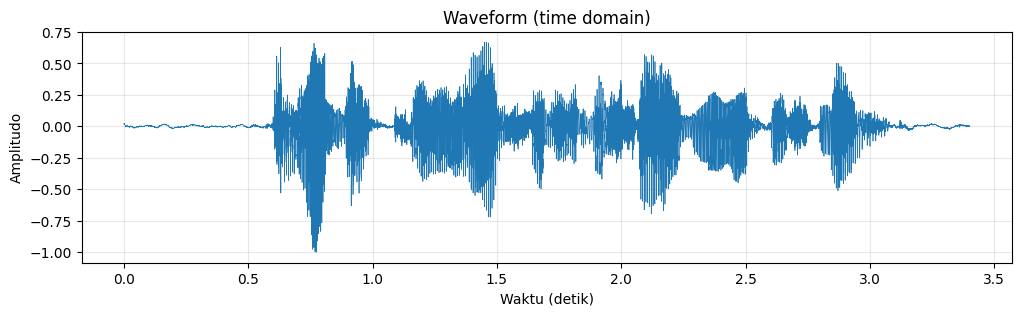

In [3]:
time = torch.arange(waveform.shape[1]) / sample_rate

plt.figure(figsize=(12, 3))
plt.plot(time, waveform[0], linewidth=0.5)
plt.title("Waveform (time domain)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(alpha=0.3)
plt.show()

---
# Bagian 3 - Memuat Model Pretrained dari Torchaudio

Torchaudio menyediakan model siap pakai dalam bentuk **bundle** di `torchaudio.pipelines`. Satu bundle berisi:
- bobot model yang sudah dilatih,
- `sample_rate` yang dipakai model,
- `labels` (daftar karakter yang bisa ditebak model).

Kita pakai **`WAV2VEC2_ASR_BASE_960H`**:
| Bagian nama | Arti |
|---|---|
| `WAV2VEC2` | arsitektur wav2vec 2.0 |
| `ASR` | sudah di-fine-tune untuk *Automatic Speech Recognition* (bisa output teks) |
| `BASE` | ukuran base: 12 layer Transformer, ±94 juta parameter |
| `960H` | di-fine-tune dengan 960 jam data LibriSpeech (bahasa Inggris) |

In [4]:
bundle = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H

print("Sample rate model :", bundle.sample_rate)
print("Labels            :", bundle.get_labels())

Sample rate model : 16000
Labels            : ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')


Arti label:
- `-` → **blank** token milik CTC (artinya "tidak ada karakter baru di frame ini").
- `|` → pemisah kata (spasi).
- `A`-`Z` dan `'` → karakter yang bisa ditebak.

Sekarang muat modelnya. **Pertama kali dijalankan, bobot model (±360 MB) akan di-download otomatis** lalu disimpan di cache.

In [5]:
model = bundle.get_model().to(device)
model.eval()   # mode inferensi (bukan training)

total_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, "-", f"{total_params:,} parameter")

Wav2Vec2Model - 94,393,245 parameter


## 3.1 Samakan sample rate

Model dilatih dengan audio **16000 Hz**. Kalau audio kita punya sample rate berbeda, kita wajib **resample** dulu. Kalau tidak, model "mendengar" suara yang terlalu cepat/lambat.

In [6]:
if sample_rate != bundle.sample_rate:
    waveform = torchaudio.functional.resample(waveform, sample_rate, bundle.sample_rate)

waveform = waveform.to(device)
print("Shape setelah resample :", tuple(waveform.shape))

Shape setelah resample : (1, 54400)


---
# Bagian 4 - Ekstraksi Fitur wav2vec

Inilah padanan **MFCC** versi deep learning. `model.extract_features()` mengembalikan **output dari setiap layer Transformer** (12 layer).

Shape tiap fitur: `(batch, frame, 768)`
- 1 frame = **20 ms** audio (CNN encoder menggeser jendela setiap 320 sample → 16000 / 320 = 50 frame per detik).
- Tiap frame direpresentasikan oleh **768 angka** (bandingkan dengan MFCC yang hanya 13 angka per frame).

In [7]:
with torch.inference_mode():          # matikan perhitungan gradient -> lebih cepat & hemat memori
    features, _ = model.extract_features(waveform)

print("Jumlah layer :", len(features))
print("Shape fitur  :", tuple(features[0].shape), "-> (batch, frame, dimensi)")
print("Frame/detik  :", round(features[0].shape[1] / (waveform.shape[1] / bundle.sample_rate)))

Jumlah layer : 12
Shape fitur  : (1, 169, 768) -> (batch, frame, dimensi)
Frame/detik  : 50


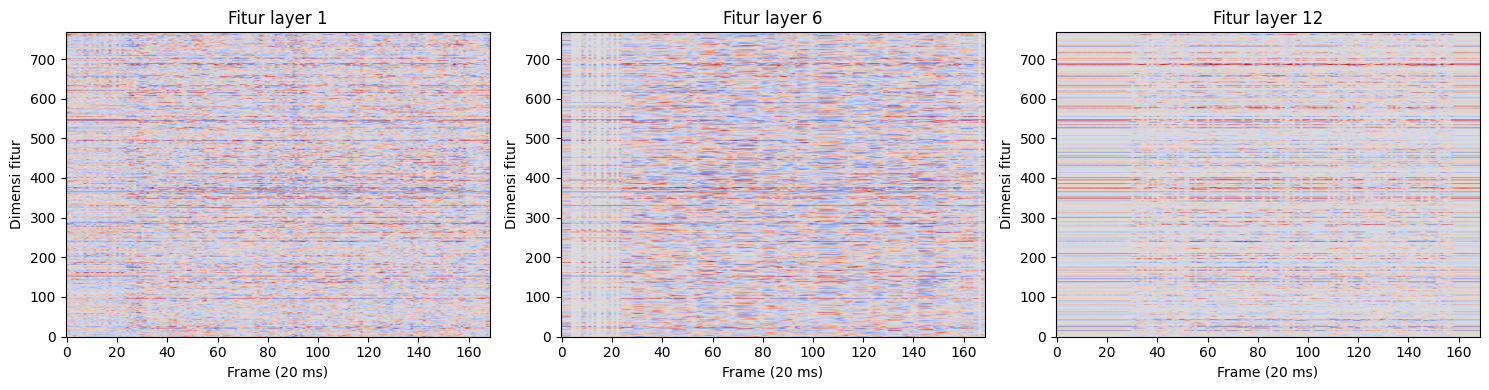

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, layer in zip(axes, [0, 5, 11]):
    feat = features[layer][0].cpu().T                 # (dimensi, frame)
    lim = feat.abs().quantile(0.98)                   # batasi skala warna agar outlier tidak mendominasi
    ax.imshow(feat, aspect="auto", origin="lower", cmap="coolwarm", vmin=-lim, vmax=lim)
    ax.set_title(f"Fitur layer {layer + 1}")
    ax.set_xlabel("Frame (20 ms)")
    ax.set_ylabel("Dimensi fitur")
plt.tight_layout()
plt.show()

Perhatikan frame 0-30 (bagian hening) polanya berbeda dari bagian yang berisi suara. Layer awal lebih dekat ke informasi akustik (mirip spektrum), layer akhir lebih dekat ke informasi **fonem/huruf**. Fitur ini bisa dipakai sebagai input model lain (klasifikasi emosi, speaker, dll.), persis seperti kita memakai MFCC.

---
# Bagian 5 - Emission

Panggil model secara langsung → kita dapat **emission** (logits): skor untuk **setiap label** di **setiap frame**.

Shape: `(batch, frame, jumlah_label)` = `(1, frame, 29)`.

In [9]:
with torch.inference_mode():
    emission, _ = model(waveform)

print("Shape emission :", tuple(emission.shape), "-> (batch, frame, label)")

Shape emission : (1, 169, 29) -> (batch, frame, label)


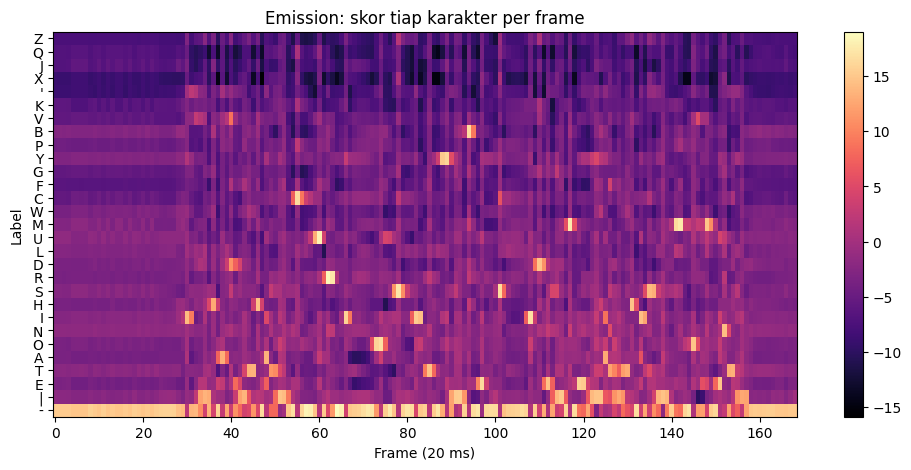

In [10]:
labels = bundle.get_labels()

plt.figure(figsize=(12, 5))
plt.imshow(emission[0].cpu().T, aspect="auto", origin="lower", cmap="magma")
plt.yticks(range(len(labels)), labels)
plt.title("Emission: skor tiap karakter per frame")
plt.xlabel("Frame (20 ms)")
plt.ylabel("Label")
plt.colorbar()
plt.show()

Bagian terang = karakter yang paling mungkin di frame tersebut. Perhatikan baris `-` (blank) sangat sering terang: kebanyakan frame berisi "bukan karakter baru".

---
# Bagian 6 - CTC Greedy Decoder

Model memberi 1 prediksi **per frame**, padahal jumlah huruf jauh lebih sedikit daripada jumlah frame. **CTC (Connectionist Temporal Classification)** menyelesaikan ini dengan aturan sederhana:

1. Ambil label dengan skor tertinggi di tiap frame (**argmax**).
2. **Gabungkan** label yang berulang berturut-turut.
3. **Buang** blank `-`.
4. Ganti `|` menjadi spasi.

Contoh:
```
argmax per frame : H H - E E - L L - - L - O O | | -
gabung berulang  : H - E - L - L - O | -
buang blank      : H E L L O |
hasil            : "HELLO"
```
Perhatikan: blank di antara `L` dan `L` membuat huruf dobel (`LL`) tetap terjaga.

In [11]:
class GreedyCTCDecoder(torch.nn.Module):
    def __init__(self, labels, blank=0):
        super().__init__()
        self.labels = labels
        self.blank = blank

    def forward(self, emission: torch.Tensor) -> str:
        # emission: (frame, label)
        indices = torch.argmax(emission, dim=-1)           # 1. label terbaik per frame
        indices = torch.unique_consecutive(indices)        # 2. gabungkan yang berulang
        indices = [i for i in indices if i != self.blank]  # 3. buang blank
        text = "".join(self.labels[i] for i in indices)
        return text.replace("|", " ").strip()              # 4. '|' -> spasi


decoder = GreedyCTCDecoder(labels)

In [12]:
# Lihat prosesnya langkah per langkah untuk frame 30-80 (frame 0-29 masih hening = blank semua)
idx = torch.argmax(emission[0], dim=-1)[30:80].cpu()
step1 = "".join(labels[i] for i in idx)
step2 = "".join(labels[i] for i in torch.unique_consecutive(idx))
step3 = step2.replace("-", "")
print("1. Argmax per frame :", step1)
print("2. Gabung berulang  :", step2)
print("3. Buang blank      :", step3)
print("4. '|' -> spasi     :", step3.replace("|", " "))

1. Argmax per frame : I--||-H-A-D-||TTH-ATT||--C----U-RR--I------OO---S-
2. Gabung berulang  : I-|-H-A-D-|TH-AT|-C-U-R-I-O-S-
3. Buang blank      : I|HAD|THAT|CURIOS
4. '|' -> spasi     : I HAD THAT CURIOS


In [13]:
transcript = decoder(emission[0].cpu())
print("Transkrip :", transcript)

Transkrip : I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT


---
# Bagian 7 - Fungsi `transcribe()`

Gabungkan semua langkah di atas menjadi satu fungsi supaya mudah dipakai untuk file audio lain.

In [14]:
def transcribe(path):
    # 1. Baca audio
    audio, sr = sf.read(path, dtype="float32")
    waveform = torch.from_numpy(audio)

    # 2. Stereo -> mono (rata-rata semua channel)
    if waveform.ndim == 2:
        waveform = waveform.mean(dim=1)
    waveform = waveform.unsqueeze(0)

    # 3. Resample ke 16 kHz
    if sr != bundle.sample_rate:
        waveform = torchaudio.functional.resample(waveform, sr, bundle.sample_rate)

    # 4. Model -> emission -> teks
    with torch.inference_mode():
        emission, _ = model(waveform.to(device))
    return decoder(emission[0].cpu())


print(transcribe("./speech.wav"))

I HAD THAT CURIOSITY BESIDE ME AT THIS MOMENT


### Coba dengan suara sendiri!
Rekam kalimat **bahasa Inggris** pendek (≤ 15 detik) dalam format `.wav`, simpan di folder ini, lalu jalankan:
```python
print(transcribe("./rekaman_saya.wav"))
```
> Model ini hanya mengenal **bahasa Inggris** (dilatih dengan LibriSpeech). Kalimat bahasa Indonesia akan "dipaksa" ditulis dengan ejaan Inggris.

---
# Bagian 8 - Rangkuman

| | MFCC (Sesi 3-4) | wav2vec 2.0 (Sesi 5) |
|---|---|---|
| Cara mendapat fitur | dirancang manual (FFT, Mel, DCT) | **dipelajari** neural network |
| Input | raw audio | raw audio |
| Ukuran fitur / frame | 13 | 768 |
| Konteks | hanya 1 frame | seluruh kalimat (Transformer) |
| Butuh training? | tidak | ya (sudah dilakukan → pretrained) |
| Output langsung teks? | tidak, perlu model lain | ya (versi ASR + CTC decoder) |

**Alur kode hari ini:**
```
speech.wav → sf.read → tensor → resample 16 kHz → model → emission → GreedyCTCDecoder → teks
```

### Latihan
1. Ganti bundle menjadi `WAV2VEC2_ASR_BASE_10M` (fine-tune hanya 10 menit data). Bandingkan transkripnya dengan `960H`.
2. Rekam suara sendiri (bahasa Inggris) dan transkripsikan dengan `transcribe()`.
3. Tambahkan noise ke audio (`waveform + level * torch.randn_like(waveform)`) dengan `level` = 0.02, 0.05, dan 0.1, lalu transkripsikan. Mulai level berapa transkripnya rusak?
4. Ambil fitur layer terakhir lalu hitung rata-ratanya terhadap waktu (`features[-1][0].mean(dim=0)`). Berapa shape-nya? Untuk apa vektor ini bisa dipakai?